# Campana de Marketing Bancario

En este cuaderno desarrollamos un EDA completo del dataset de marketing bancario y construimos un modelo de regresion logistica para predecir si un cliente contratara o no un deposito a largo plazo.


### Paso 1: Carga del conjunto de datos


In [1]:
from pathlib import Path
import warnings

# Librerias base para analisis y visualizacion
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas del modelo de clasificacion
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

# Ocultamos warnings numericos para que el cuaderno quede mas limpio
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

# Detectamos la raiz del proyecto para que las rutas funcionen
try:
    project_dir = Path.cwd().resolve()
except FileNotFoundError:
    project_dir = Path("/Users/dragcessa/Desktop/Dragcessa1998-tutorial-de-Proyecto-de-Regresi-n-Log-stica")

if not (project_dir / "data").exists() and (project_dir.parent / "data").exists():
    project_dir = project_dir.parent

raw_dir = project_dir / "data" / "raw"
processed_dir = project_dir / "data" / "processed"
raw_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)


In [2]:
# Cargamos el dataset directamente desde la URL del proyecto
url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"
total_data = pd.read_csv(url, sep=";")
total_data.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no


In [3]:
# Guardamos una copia del dataset original en data/raw
raw_path = raw_dir / "bank-marketing-campaign-data.csv"
total_data.to_csv(raw_path, index=False)
print(f"Archivo guardado en: {raw_path}")


Archivo guardado en: /Users/dragcessa/Desktop/Dragcessa1998-tutorial-de-Proyecto-de-Regresi-n-Log-stica/data/raw/bank-marketing-campaign-data.csv


### Paso 2: EDA completo


En esta parte buscamos entender la estructura del dataset, detectar problemas de calidad y observar relaciones iniciales con la variable objetivo. La idea es justificar despues cada decision de limpieza y modelado.


In [4]:
# Revisamos rapidamente cuantas filas y columnas tiene el dataset
total_data.shape


(41188, 21)

El dataset contiene 41,188 registros y 21 variables. Antes de modelar necesitamos revisar tipos de datos, valores faltantes, duplicados y la distribucion de la variable objetivo.


In [5]:
# Vemos tipos de datos, columnas y valores no nulos
total_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [6]:
# Resumen estadistico para entender el rango y la dispersion de las variables
total_data.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,"41,188.00",NaN,NaN,NaN,40.02,10.42,17.00,32.00,38.00,47.00,98.00
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# En este dataset muchos faltantes vienen como texto "unknown"
# Aqui contamos en que columnas aparece para decidir luego como tratarlos
unknown_counts = (total_data == "unknown").sum()
unknown_counts[unknown_counts > 0].sort_values(ascending=False).to_frame("unknown_values")


,unknown_values
default,8597
education,1731
housing,990
loan,990
job,330
marital,80


In [8]:
# Contamos filas duplicadas exactas
total_data.duplicated().sum()


np.int64(12)

y
no     36548
yes     4640
Name: count, dtype: int64

,percentage
y,
no,88.73
yes,11.27


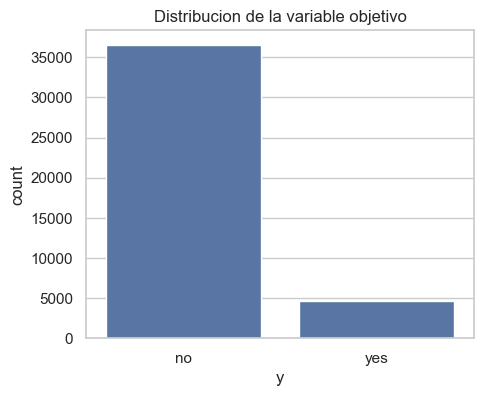

In [9]:
# Revisamos el balance de la variable objetivo
# Esto es importante porque si el dataset esta desbalanceado accuracy no basta
display(total_data["y"].value_counts())
display(total_data["y"].value_counts(normalize=True).mul(100).round(2).to_frame("percentage"))
plt.figure(figsize=(5, 4))
sns.countplot(data=total_data, x="y")
plt.title("Distribucion de la variable objetivo")
plt.show()


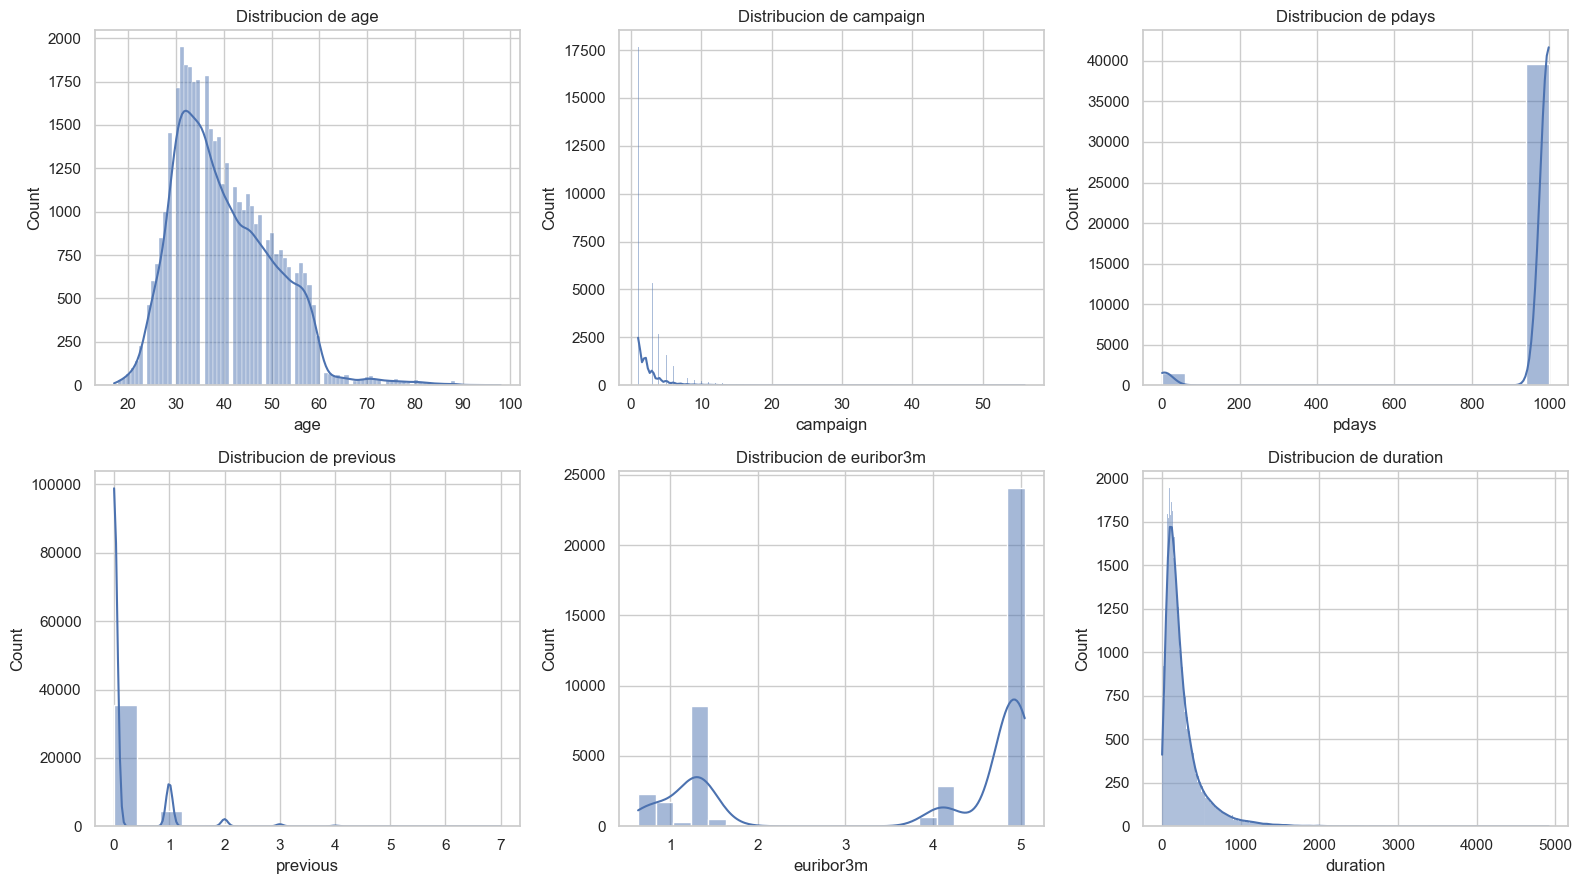

In [10]:
# Observamos la forma de algunas variables numericas relevantes
numeric_columns = ["age", "campaign", "pdays", "previous", "euribor3m", "duration"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, column in zip(axes.flatten(), numeric_columns):
    sns.histplot(total_data[column], kde=True, ax=ax)
    ax.set_title(f"Distribucion de {column}")
plt.tight_layout()


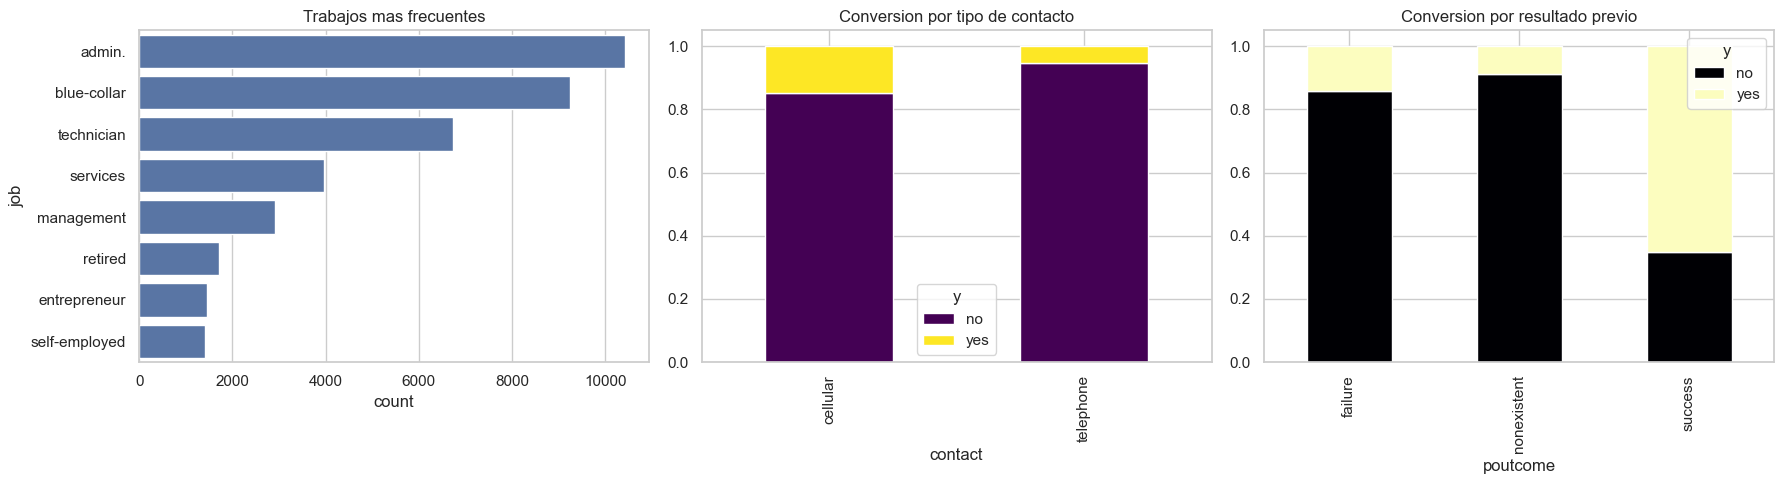

In [11]:
# Analizamos algunas variables categoricas para detectar patrones de conversion
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=total_data, y="job", order=total_data["job"].value_counts().index[:8], ax=axes[0])
axes[0].set_title("Trabajos mas frecuentes")

pd.crosstab(total_data["contact"], total_data["y"], normalize="index").plot(kind="bar", stacked=True, ax=axes[1], colormap="viridis")
axes[1].set_title("Conversion por tipo de contacto")
axes[1].legend(title="y")

pd.crosstab(total_data["poutcome"], total_data["y"], normalize="index").plot(kind="bar", stacked=True, ax=axes[2], colormap="magma")
axes[2].set_title("Conversion por resultado previo")
axes[2].legend(title="y")

plt.tight_layout()


### Limpieza de datos


A partir del EDA hacemos una limpieza sencilla y visible: quitar duplicados, convertir `unknown` en faltantes, eliminar `duration` por fuga de informacion e imputar los valores faltantes con criterios simples.


In [12]:
# Creamos una copia para no modificar el dataset original
clean_data = total_data.copy()
print(f"Registros antes de eliminar duplicados: {clean_data.shape[0]}")

# Eliminamos filas duplicadas exactas
clean_data = clean_data.drop_duplicates()
print(f"Registros despues de eliminar duplicados: {clean_data.shape[0]}")


Registros antes de eliminar duplicados: 41188
Registros despues de eliminar duplicados: 41176


In [13]:
# Convertimos el texto "unknown" a NaN para tratarlo como valor faltante real
clean_data = clean_data.replace("unknown", np.nan)
clean_data.isna().sum()[clean_data.isna().sum() > 0].sort_values(ascending=False).to_frame("missing_values")


,missing_values
default,8596
education,1730
housing,990
loan,990
job,330
marital,80


La variable `duration` tiene mucha relacion con la conversion, pero no es conveniente usarla para el modelo porque solo se conoce despues de la llamada. Para evitar fuga de informacion, la eliminamos del dataset de modelado.


In [14]:
# Eliminamos duration por fuga de informacion
columns_to_drop = ["duration"]
clean_data = clean_data.drop(columns=columns_to_drop)
print(f"Columnas eliminadas: {columns_to_drop}")
clean_data.head()


Columnas eliminadas: ['duration']


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.10,93.99,-36.40,4.86,"5,191.00",no


In [15]:
# Separamos columnas categoricas y numericas para imputar con estrategias simples
categorical_columns = clean_data.select_dtypes(include="object").columns.tolist()
categorical_columns.remove("y")
numeric_columns = clean_data.select_dtypes(include="number").columns.tolist()

# Las categoricas se rellenan con la moda
for column in categorical_columns:
    clean_data[column] = clean_data[column].fillna(clean_data[column].mode()[0])

# Las numericas se rellenan con la mediana
for column in numeric_columns:
    clean_data[column] = clean_data[column].fillna(clean_data[column].median())

# Comprobamos que ya no queden faltantes
clean_data.isna().sum().sum()


np.int64(0)

In [16]:
# Guardamos la version limpia para dejar trazabilidad del proceso
clean_path = processed_dir / "bank_marketing_clean.csv"
clean_data.to_csv(clean_path, index=False)
print(f"Archivo limpio guardado en: {clean_path}")


Archivo limpio guardado en: /Users/dragcessa/Desktop/Dragcessa1998-tutorial-de-Proyecto-de-Regresi-n-Log-stica/data/processed/bank_marketing_clean.csv


### Preparacion para el modelo


Antes de entrenar el modelo necesitamos convertir la informacion categorica a formato numerico, separar `X` e `y`, y dividir el dataset en entrenamiento y prueba de forma reproducible.


In [17]:
# Separamos variables predictoras y variable objetivo
X = clean_data.drop(columns=["y"])
y = clean_data["y"].map({"no": 0, "yes": 1})

# Convertimos variables categoricas a formato numerico con dummies
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head()


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,1,999,0,1.10,93.99,-36.40,4.86,"5,191.00",0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
1,57,1,999,0,1.10,93.99,-36.40,4.86,"5,191.00",0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
2,37,1,999,0,1.10,93.99,-36.40,4.86,"5,191.00",0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
3,40,1,999,0,1.10,93.99,-36.40,4.86,"5,191.00",0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0
4,56,1,999,0,1.10,93.99,-36.40,4.86,"5,191.00",0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0


In [18]:
# Dividimos el dataset en train y test manteniendo la proporcion de la clase objetivo
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (32940, 46)
X_test shape: (8236, 46)
y_train shape: (32940,)
y_test shape: (8236,)


In [19]:
# Guardamos los conjuntos ya preparados para futuras pruebas
train_data = X_train.copy()
train_data["y"] = y_train.values
test_data = X_test.copy()
test_data["y"] = y_test.values

train_path = processed_dir / "bank_marketing_train.csv"
test_path = processed_dir / "bank_marketing_test.csv"
train_data.to_csv(train_path, index=False)
test_data.to_csv(test_path, index=False)
print(f"Train guardado en: {train_path}")
print(f"Test guardado en: {test_path}")


Train guardado en: /Users/dragcessa/Desktop/Dragcessa1998-tutorial-de-Proyecto-de-Regresi-n-Log-stica/data/processed/bank_marketing_train.csv
Test guardado en: /Users/dragcessa/Desktop/Dragcessa1998-tutorial-de-Proyecto-de-Regresi-n-Log-stica/data/processed/bank_marketing_test.csv


In [20]:
# Escalamos solo las variables numericas para estabilizar la regresion logistica
# Las columnas dummy no necesitan este paso
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])
X_train_scaled.head()


,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,default_yes,housing_yes,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
36454,-1.53,-0.20,0.20,1.66,-1.90,-1.06,-0.06,-1.36,-1.25,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0
1233,-0.77,-0.56,0.20,-0.35,0.65,0.72,0.89,0.71,0.33,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0
24111,-0.67,-0.56,0.20,-0.35,-0.11,-0.65,-0.32,0.36,0.40,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0
15516,-0.19,0.52,0.20,-0.35,0.84,0.59,-0.47,0.77,0.85,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0
17916,-0.10,0.52,0.20,-0.35,0.84,0.59,-0.47,0.77,0.85,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0


### Paso 3: Modelo de regresion logistica base


Primero entrenamos una regresion logistica base para tener una referencia. Luego compararemos esa referencia con una version optimizada.


In [21]:
# Entrenamos un primer modelo con una configuracion base
baseline_model = LogisticRegression(max_iter=4000, solver="liblinear")
baseline_model.fit(X_train_scaled, y_train)

# Generamos predicciones y probabilidades
y_pred = baseline_model.predict(X_test_scaled)
y_pred_proba = baseline_model.predict_proba(X_test_scaled)[:, 1]

# Calculamos metricas principales
baseline_metrics = {
    "accuracy": round(accuracy_score(y_test, y_pred), 4),
    "precision": round(precision_score(y_test, y_pred), 4),
    "recall": round(recall_score(y_test, y_pred), 4),
    "f1": round(f1_score(y_test, y_pred), 4),
    "roc_auc": round(roc_auc_score(y_test, y_pred_proba), 4)
}

baseline_metrics


{'accuracy': 0.8986,
 'precision': 0.6566,
 'recall': 0.2101,
 'f1': 0.3184,
 'roc_auc': np.float64(0.7998)}

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7308
           1       0.66      0.21      0.32       928

    accuracy                           0.90      8236
   macro avg       0.78      0.60      0.63      8236
weighted avg       0.88      0.90      0.87      8236



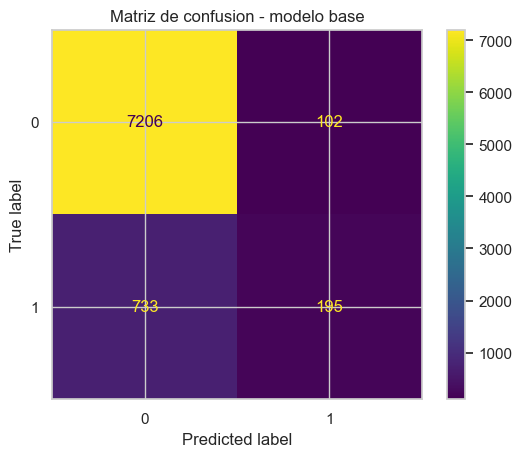

In [22]:
# Reporte mas detallado del modelo base
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Matriz de confusion - modelo base")
plt.show()


### Paso 4: Optimizacion del modelo


La optimizacion no busca complejidad extrema: solo probamos algunos valores de regularizacion y el uso de `class_weight=balanced` para mejorar el comportamiento sobre la clase positiva.


In [23]:
# Probamos varias combinaciones simples para mejorar el F1-score
param_grid = {
    "C": [0.01, 0.1, 1, 3, 10],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=4000, solver="liblinear"),
    param_grid=param_grid,
    scoring="f1",
    cv=5
)

grid_search.fit(X_train_scaled, y_train)
grid_search.best_params_


{'C': 10, 'class_weight': 'balanced'}

In [24]:
# Evaluamos el mejor modelo encontrado por GridSearchCV
optimized_model = grid_search.best_estimator_
optimized_pred = optimized_model.predict(X_test_scaled)
optimized_pred_proba = optimized_model.predict_proba(X_test_scaled)[:, 1]

optimized_metrics = {
    "accuracy": round(accuracy_score(y_test, optimized_pred), 4),
    "precision": round(precision_score(y_test, optimized_pred), 4),
    "recall": round(recall_score(y_test, optimized_pred), 4),
    "f1": round(f1_score(y_test, optimized_pred), 4),
    "roc_auc": round(roc_auc_score(y_test, optimized_pred_proba), 4)
}

optimized_metrics


{'accuracy': 0.8312,
 'precision': 0.3607,
 'recall': 0.6444,
 'f1': 0.4625,
 'roc_auc': np.float64(0.7994)}

              precision    recall  f1-score   support

           0       0.95      0.85      0.90      7308
           1       0.36      0.64      0.46       928

    accuracy                           0.83      8236
   macro avg       0.66      0.75      0.68      8236
weighted avg       0.88      0.83      0.85      8236



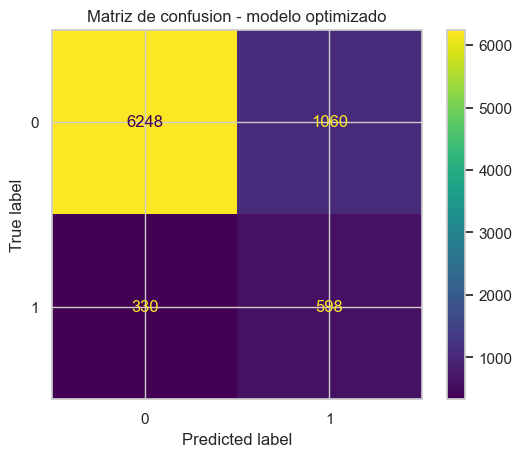

In [25]:
# Reporte detallado del modelo optimizado
print(classification_report(y_test, optimized_pred))
ConfusionMatrixDisplay.from_predictions(y_test, optimized_pred)
plt.title("Matriz de confusion - modelo optimizado")
plt.show()


In [26]:
# Comparamos ambos modelos en una sola tabla y la guardamos
comparison = pd.DataFrame([
    {"model": "baseline_logistic_regression", **baseline_metrics},
    {"model": "optimized_logistic_regression", **optimized_metrics}
])
comparison_path = processed_dir / "bank_marketing_model_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print(f"Comparacion de modelos guardada en: {comparison_path}")
comparison


Comparacion de modelos guardada en: /Users/dragcessa/Desktop/Dragcessa1998-tutorial-de-Proyecto-de-Regresi-n-Log-stica/data/processed/bank_marketing_model_comparison.csv


,model,accuracy,precision,recall,f1,roc_auc
0,baseline_logistic_regression,0.90,0.66,0.21,0.32,0.80
1,optimized_logistic_regression,0.83,0.36,0.64,0.46,0.80


In [27]:
# Revisamos las variables con mayor peso absoluto en el modelo optimizado
coefficients = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": optimized_model.coef_[0]
})

coefficients["abs_coefficient"] = coefficients["coefficient"].abs()
coefficients.sort_values("abs_coefficient", ascending=False).head(10).drop(columns="abs_coefficient")


,feature,coefficient
4,emp.var.rate,-2.36
35,month_mar,1.55
27,default_yes,-1.21
5,cons.price.idx,1.17
24,education_illiterate,0.73
31,month_aug,0.72
32,month_dec,0.71
45,poutcome_success,0.69
30,contact_telephone,-0.66
34,month_jun,-0.62


### Conclusiones

- El dataset esta desbalanceado: la mayoria de clientes no contrata el deposito.
- Se eliminaron duplicados y se trataron los valores `unknown` como faltantes.
- `duration` se elimino para evitar fuga de informacion en el modelo.
- El modelo base ofrece buena accuracy, pero bajo recall para la clase positiva.
- El modelo optimizado con `class_weight=balanced` mejora el recall y el F1-score, por lo que resulta mas util para detectar clientes con probabilidad de suscribirse.
